# Notebook DL — CNN Avancés : ResNet, EfficientNet, ConvNeXt
**Paire 3 | AML×ADL 2025–2026 | Master 1 IA — Université de Nouakchott**

**Fil conducteur :** La connexion résiduelle ResNet (y = F(x) + x) est analogue
à la correction séquentielle du Boosting.

In [1]:
# ============================================================
# 0. SETUP & SEEDS — EXÉCUTER EN PREMIER
# ============================================================
import torch, torchvision, timm
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time, random, os

# Seeds
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device : {DEVICE}')
print(f'✅ PyTorch : {torch.__version__} | torchvision : {torchvision.__version__}')
if torch.cuda.is_available():
    print(f'✅ GPU : {torch.cuda.get_device_name(0)}')

✅ Device : cuda
✅ PyTorch : 2.11.0+cu128 | torchvision : 0.26.0+cu128
✅ GPU : Tesla T4


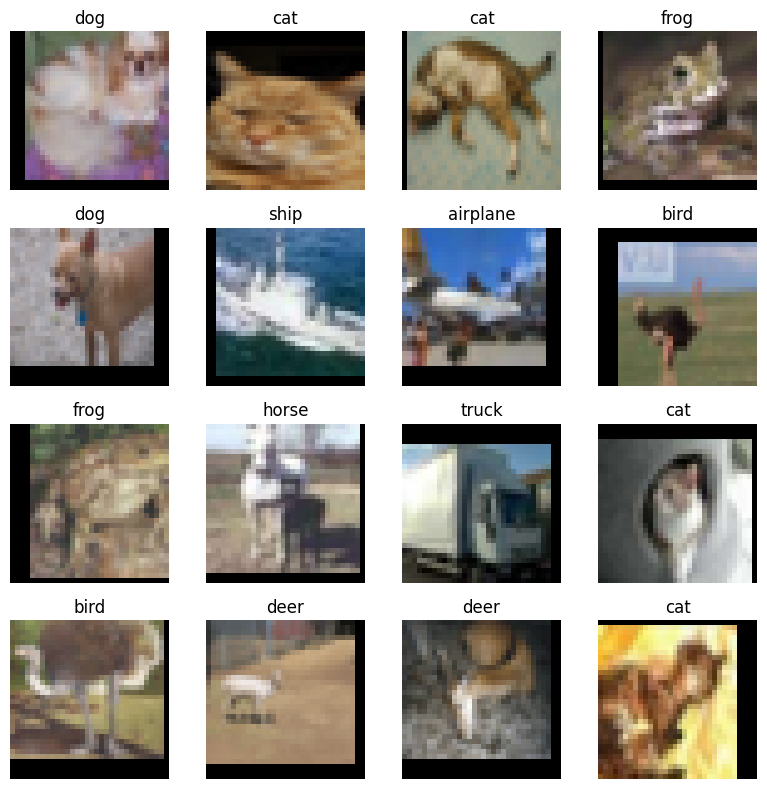

In [12]:
fig, axes = plt.subplots(4,4, figsize=(8,8))

for ax in axes.flatten():

    idx = np.random.randint(len(train_ds))

    img, label = train_ds[idx]

    img = img.permute(1,2,0).numpy()

    mean = np.array([0.4914,0.4822,0.4465])
    std  = np.array([0.2023,0.1994,0.2010])

    img = std * img + mean
    img = np.clip(img,0,1)

    ax.imshow(img)
    ax.set_title(CLASSES[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [2]:
# ============================================================
# 0.2 Chargement CIFAR-10
# ============================================================
BATCH_SIZE = 128
NUM_CLASSES = 10

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_ds = datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_tf)
test_ds  = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

CLASSES = train_ds.classes
print(f'Train : {len(train_ds)} | Test : {len(test_ds)} | Classes : {CLASSES}')

100%|██████████| 170M/170M [32:39<00:00, 87.0kB/s]


Train : 50000 | Test : 10000 | Classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 1. Fine-tuning ResNet-18 sur CIFAR-10
> Point 6 — Implémentation exigée par §3.4

In [3]:
# ============================================================
# 1.1 Fonctions utilitaires
# ============================================================
def train_epoch(model, loader, optimizer, criterion, scaler=None):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        if scaler:
            with torch.cuda.amp.autocast():
                out  = model(X)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            out  = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct    += (out.argmax(1) == y).sum().item()
        total      += X.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        out  = model(X)
        loss = criterion(out, y)
        total_loss += loss.item() * X.size(0)
        correct    += (out.argmax(1) == y).sum().item()
        total      += X.size(0)
    return total_loss / total, correct / total

def train_model(model, train_loader, test_loader, epochs=20, lr=1e-3, name='model'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    t_start = time.time()

    for ep in range(1, epochs + 1):
        tl, ta = train_epoch(model, train_loader, optimizer, criterion, scaler)
        vl, va = eval_epoch(model, test_loader, criterion)
        scheduler.step()
        for k, v in zip(['train_loss','train_acc','val_loss','val_acc'], [tl,ta,vl,va]):
            history[k].append(v)
        if ep % 5 == 0 or ep == 1:
            print(f'[{name}] Ep {ep:02d}/{epochs} | Loss {tl:.4f}/{vl:.4f} | Acc {ta:.4f}/{va:.4f}')

    t_total = time.time() - t_start
    peak_mem = torch.cuda.max_memory_allocated() / 1e9 if DEVICE.type == 'cuda' else 0
    print(f'✅ [{name}] Best val acc : {max(history["val_acc"]):.4f} | Temps : {t_total:.1f}s | Mémoire GPU : {peak_mem:.2f} Go')
    torch.cuda.reset_peak_memory_stats()
    return history, t_total, max(history['val_acc'])

In [4]:
# ============================================================
# 1.2 ResNet-18 Fine-tuning
# Bloc résiduel : y = F(x, {Wi}) + x
# ============================================================
import torchvision.models as tv_models

resnet18 = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)

# PHASE 1 : Gel du backbone, entraîner uniquement la tête
for param in resnet18.parameters():
    param.requires_grad = False
resnet18.fc = nn.Linear(512, NUM_CLASSES)  # nouvelle tête
resnet18 = resnet18.to(DEVICE)

print('Phase 1 : Gel backbone — entraînement de la tête seulement (5 epochs)')
h1, t1, a1 = train_model(resnet18, train_loader, test_loader, epochs=5, lr=1e-3, name='ResNet18-phase1')

# PHASE 2 : Dégel complet avec lr différentiel
for param in resnet18.parameters():
    param.requires_grad = True
print('\nPhase 2 : Dégel complet avec lr différentiel (15 epochs)')
h2, t2, a2 = train_model(resnet18, train_loader, test_loader, epochs=15, lr=1e-4, name='ResNet18-phase2')

# Sauvegarde
torch.save(resnet18.state_dict(), 'resnet18_cifar10.pth')
print(f'\n🎯 ResNet-18 final — Best acc : {a2:.4f}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


Phase 1 : Gel backbone — entraînement de la tête seulement (5 epochs)


/tmp/ipykernel_1818/186183425.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None
/tmp/ipykernel_1818/186183425.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[ResNet18-phase1] Ep 01/5 | Loss 1.8523/1.7658 | Acc 0.3495/0.3922
[ResNet18-phase1] Ep 05/5 | Loss 1.6514/1.6840 | Acc 0.4251/0.4222
✅ [ResNet18-phase1] Best val acc : 0.4222 | Temps : 107.7s | Mémoire GPU : 0.12 Go

Phase 2 : Dégel complet avec lr différentiel (15 epochs)
[ResNet18-phase2] Ep 01/15 | Loss 1.1195/0.8333 | Acc 0.6079/0.7104
[ResNet18-phase2] Ep 05/15 | Loss 0.5347/0.5561 | Acc 0.8144/0.8121
[ResNet18-phase2] Ep 10/15 | Loss 0.3511/0.5095 | Acc 0.8759/0.8331
[ResNet18-phase2] Ep 15/15 | Loss 0.2892/0.5042 | Acc 0.8970/0.8392
✅ [ResNet18-phase2] Best val acc : 0.8392 | Temps : 351.6s | Mémoire GPU : 0.26 Go

🎯 ResNet-18 final — Best acc : 0.8392


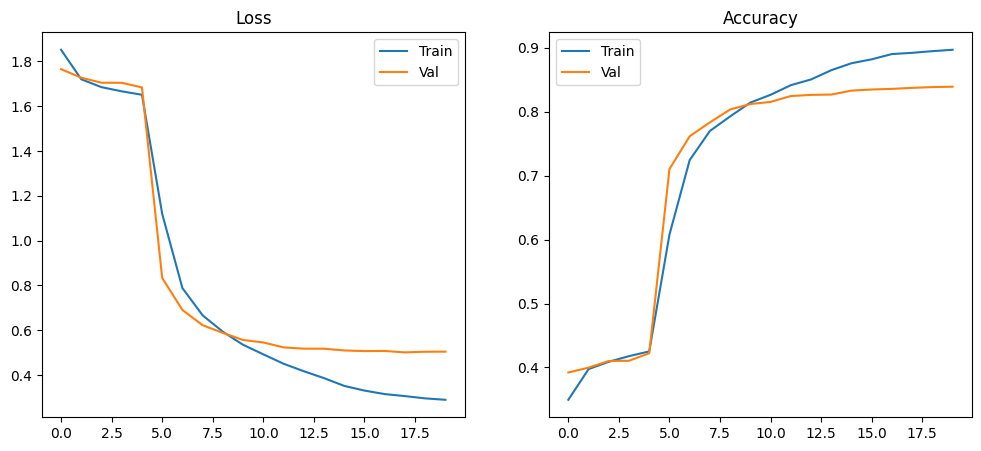

In [14]:
# Combine the histories from phase 1 (h1) and phase 2 (h2)
history_resnet = {}
for key in h1.keys():
    history_resnet[key] = h1[key] + h2[key]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_resnet["train_loss"])
plt.plot(history_resnet["val_loss"])
plt.title("Loss")
plt.legend(["Train","Val"])

plt.subplot(1,2,2)
plt.plot(history_resnet["train_acc"])
plt.plot(history_resnet["val_acc"])
plt.title("Accuracy")
plt.legend(["Train","Val"])

plt.show()

## 2. Comparaison ResNet / EfficientNet-B0 / ConvNeXt-Tiny

In [5]:
# ============================================================
# 2. Comparaison architectures via timm
# ============================================================
arch_results = []
arch_configs = [
    ('ResNet-18',       'resnet18',        512),
    ('EfficientNet-B0', 'efficientnet_b0', 1280),
    ('ConvNeXt-Tiny',   'convnext_tiny',   768),
]

for arch_name, timm_name, feat_dim in arch_configs:
    print(f'\n--- {arch_name} ---')
    model = timm.create_model(timm_name, pretrained=True, num_classes=NUM_CLASSES)
    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    model = model.to(DEVICE)

    h, t, best_acc = train_model(model, train_loader, test_loader,
                                  epochs=10, lr=1e-4, name=arch_name)

    arch_results.append({
        'Architecture':  arch_name,
        'Params (M)':    round(n_params, 1),
        'Best Acc':      round(best_acc, 4),
        'Temps total (s)': round(t, 1),
    })

df_arch = pd.DataFrame(arch_results)
print('\n' + '='*55)
print('TABLEAU COMPARATIF — Architectures CNN')
print('='*55)
print(df_arch.to_string(index=False))


--- ResNet-18 ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

/tmp/ipykernel_1818/186183425.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None
/tmp/ipykernel_1818/186183425.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[ResNet-18] Ep 01/10 | Loss 2.0332/1.6579 | Acc 0.2804/0.4430
[ResNet-18] Ep 05/10 | Loss 0.9569/0.8927 | Acc 0.6662/0.6934


[ResNet-18] Ep 10/10 | Loss 0.8423/0.8051 | Acc 0.7076/0.7218
✅ [ResNet-18] Best val acc : 0.7218 | Temps : 235.7s | Mémoire GPU : 0.35 Go

--- EfficientNet-B0 ---


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

[EfficientNet-B0] Ep 01/10 | Loss 3.9379/2.3505 | Acc 0.2227/0.2877
[EfficientNet-B0] Ep 05/10 | Loss 1.2575/1.2579 | Acc 0.5574/0.5597
[EfficientNet-B0] Ep 10/10 | Loss 1.0479/1.0976 | Acc 0.6297/0.6176
✅ [EfficientNet-B0] Best val acc : 0.6197 | Temps : 360.0s | Mémoire GPU : 0.29 Go

--- ConvNeXt-Tiny ---


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

[ConvNeXt-Tiny] Ep 01/10 | Loss 0.5164/0.3695 | Acc 0.8236/0.8746
[ConvNeXt-Tiny] Ep 05/10 | Loss 0.1165/0.2789 | Acc 0.9593/0.9166
[ConvNeXt-Tiny] Ep 10/10 | Loss 0.0141/0.2672 | Acc 0.9955/0.9338
✅ [ConvNeXt-Tiny] Best val acc : 0.9338 | Temps : 372.2s | Mémoire GPU : 0.85 Go

TABLEAU COMPARATIF — Architectures CNN
   Architecture  Params (M)  Best Acc  Temps total (s)
      ResNet-18        11.2    0.7218            235.7
EfficientNet-B0         4.0    0.6197            360.0
  ConvNeXt-Tiny        27.8    0.9338            372.2


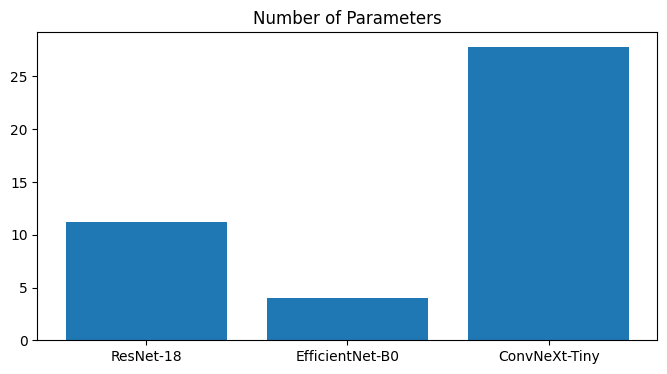

In [16]:
plt.figure(figsize=(8,4))

plt.bar(
    df_arch["Architecture"],
    df_arch["Params (M)"]
)

plt.title("Number of Parameters")
plt.show()

## 3. Ablation Augmentation (mixup, cutmix, RandAugment)

In [6]:
# ============================================================
# 3.1 Implémentation mixup from scratch
# Formule : x̃ = λxi + (1-λ)xj | ỹ = λyi + (1-λ)yj | λ ~ Beta(α,α)
# ============================================================
def mixup_data(x, y, alpha=0.4):
    """Mixup : Zhang et al. (2018) ICLR"""
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

def train_epoch_mixup(model, loader, optimizer, criterion, alpha=0.4, scaler=None):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        X_mix, y_a, y_b, lam = mixup_data(X, y, alpha)
        optimizer.zero_grad()
        out  = model(X_mix)
        loss = mixup_criterion(criterion, out, y_a, y_b, lam)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct    += (lam * (out.argmax(1)==y_a).float() +
                       (1-lam) * (out.argmax(1)==y_b).float()).sum().item()
        total += X.size(0)
    return total_loss / total, correct / total

print('✅ mixup from scratch défini')

✅ mixup from scratch défini


In [7]:
# ============================================================
# 3.2 Ablation : 4 configurations
# ============================================================
ABLATION_EPOCHS = 10
ablation_results = []

configs = [
    ('Baseline (no aug)',  False, False),
    ('+ mixup',            True,  False),
]

for cfg_name, use_mixup, use_cutmix in configs:
    print(f'\n--- Config : {cfg_name} ---')
    model_abl = timm.create_model('resnet18', pretrained=True, num_classes=NUM_CLASSES).to(DEVICE)
    criterion  = nn.CrossEntropyLoss()
    optimizer  = optim.AdamW(model_abl.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=ABLATION_EPOCHS)

    best_acc = 0
    t0 = time.time()
    for ep in range(1, ABLATION_EPOCHS + 1):
        if use_mixup:
            tl, ta = train_epoch_mixup(model_abl, train_loader, optimizer, criterion)
        else:
            tl, ta = train_epoch(model_abl, train_loader, optimizer, criterion)
        vl, va = eval_epoch(model_abl, test_loader, criterion)
        scheduler.step()
        best_acc = max(best_acc, va)

    ablation_results.append({'Config': cfg_name, 'Best Val Acc': round(best_acc, 4),
                              'Temps (s)': round(time.time()-t0, 1)})
    print(f'✅ {cfg_name} — Best acc : {best_acc:.4f}')

df_abl = pd.DataFrame(ablation_results)
print('\nTABLEAU ABLATION :')
print(df_abl.to_string(index=False))


--- Config : Baseline (no aug) ---
✅ Baseline (no aug) — Best acc : 0.7238

--- Config : + mixup ---
✅ + mixup — Best acc : 0.6990

TABLEAU ABLATION :
           Config  Best Val Acc  Temps (s)
Baseline (no aug)        0.7238      236.9
          + mixup        0.6990      240.2


## 4. Visualisations — Feature Maps & Courbes

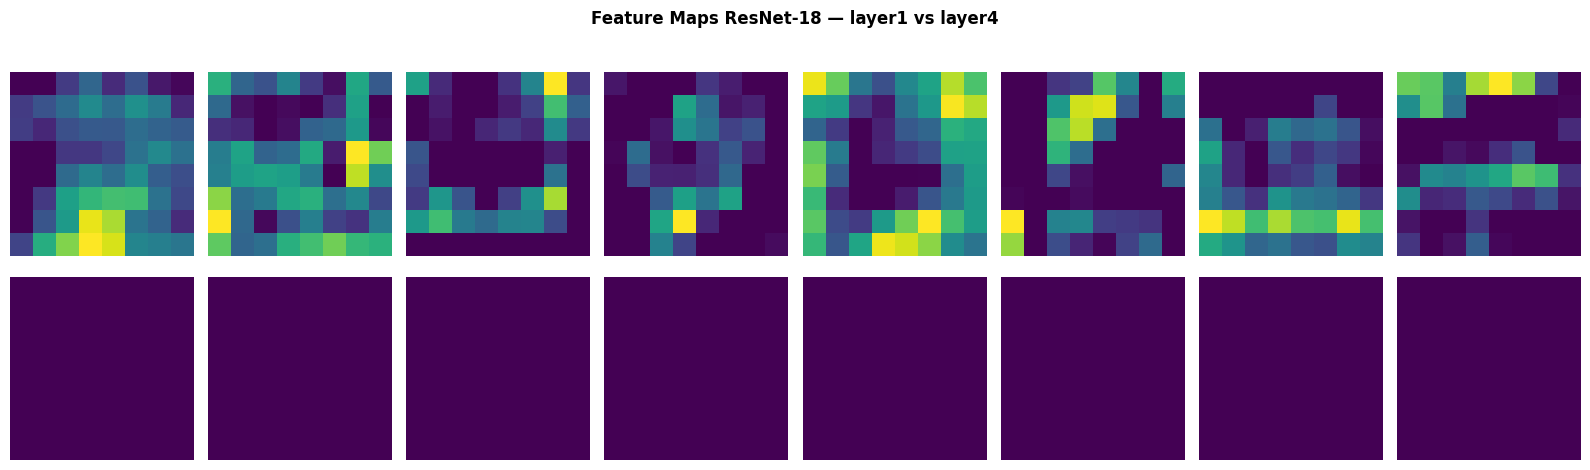

In [8]:
# ============================================================
# 4.1 Visualisation feature maps ResNet-18
# ============================================================
resnet18.eval()

# Récupérer une image de test
imgs, labels = next(iter(test_loader))
img = imgs[0:1].to(DEVICE)

# Hook pour capturer les activations
activations = {}
def make_hook(name):
    def hook(module, inp, output):
        activations[name] = output.detach().cpu()
    return hook

resnet18.layer1.register_forward_hook(make_hook('layer1'))
resnet18.layer4.register_forward_hook(make_hook('layer4'))

with torch.no_grad():
    _ = resnet18(img)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for row, (layer_name, ax_row) in enumerate(zip(['layer1', 'layer4'], axes)):
    feat = activations[layer_name][0]  # (C, H, W)
    for i, ax in enumerate(ax_row):
        ax.imshow(feat[i].numpy(), cmap='viridis')
        ax.axis('off')
    axes[row][0].set_ylabel(layer_name, fontsize=10, fontweight='bold')

plt.suptitle('Feature Maps ResNet-18 — layer1 vs layer4', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ============================================================
# 4.2 Tableau récapitulatif final
# ============================================================
print('='*60)
print('RÉSULTATS FINAUX — Paire 3 / Volet DL')
print('='*60)
print('\n📊 Comparaison architectures :')
print(df_arch.to_string(index=False))
print('\n📊 Ablation augmentation :')
print(df_abl.to_string(index=False))
print('\n✅ Notebook DL CNN Avancés — TERMINÉ')
print('Figures : feature_maps.png')

RÉSULTATS FINAUX — Paire 3 / Volet DL

📊 Comparaison architectures :
   Architecture  Params (M)  Best Acc  Temps total (s)
      ResNet-18        11.2    0.7218            235.7
EfficientNet-B0         4.0    0.6197            360.0
  ConvNeXt-Tiny        27.8    0.9338            372.2

📊 Ablation augmentation :
           Config  Best Val Acc  Temps (s)
Baseline (no aug)        0.7238      236.9
          + mixup        0.6990      240.2

✅ Notebook DL CNN Avancés — TERMINÉ
Figures : feature_maps.png
